## Visual Examples of Threedx Forecasts

Visualizations of forecasts along with their input time series are often the most interesting part about a paper reporting on new methods. So let's take a look at some Threedx forecasts for some of the datasets included in the corpus on which the Chronos models were trained, [available on Hugging Face](https://huggingface.co/datasets/autogluon/chronos_datasets). That makes it easy to load the data by not doing much more than importing `datasets`.

In [1]:
import datasets
import numpy as np
import threedx as tdx
from threedx.graphics import plot_forecast

In [2]:
# Without tuning the parameters to a given use case, we can define the
# parameter grid once upfront and re-use it across datasets and time series.
parameter_grid = tdx.initialize_parameters_at_random(
    size=5000,
    seed=72,
    include_edge_cases=True,
)

### Car Parts

The Car Parts dataset is a classic example of intermittent time series. Very intermittent time series. The observations are recorded on a monthly basis for a couple of years. There are 2674 series.

Assume `period_length=12` and forecast the last observed period (twelve months).

In [3]:
ds_car_parts = datasets.load_dataset("autogluon/chronos_datasets", "monash_car_parts", split="train")
ds_car_parts.set_format("numpy")

print(f"{len(ds_car_parts)=}")

len(ds_car_parts)=2674


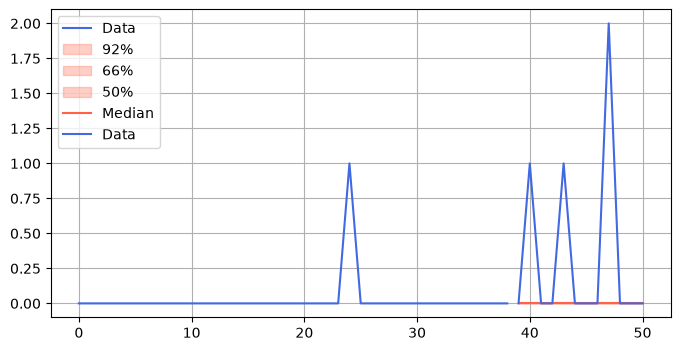

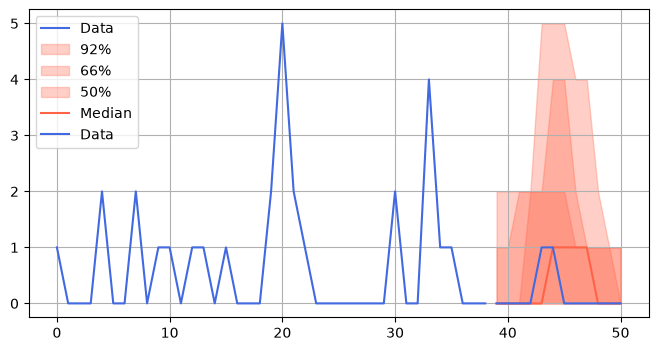

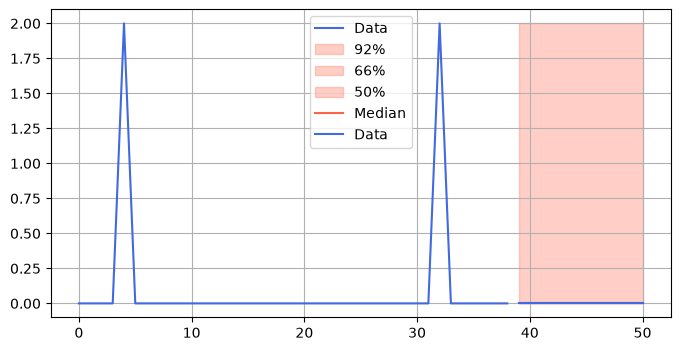

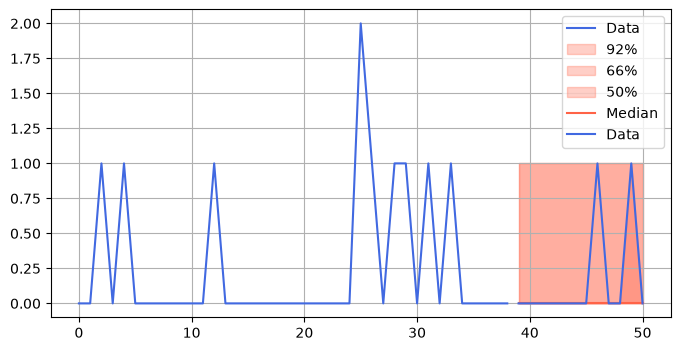

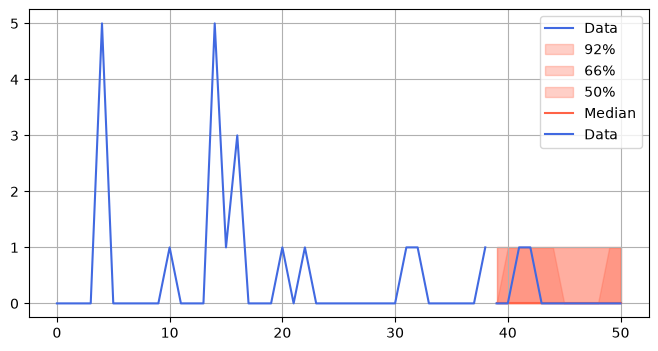

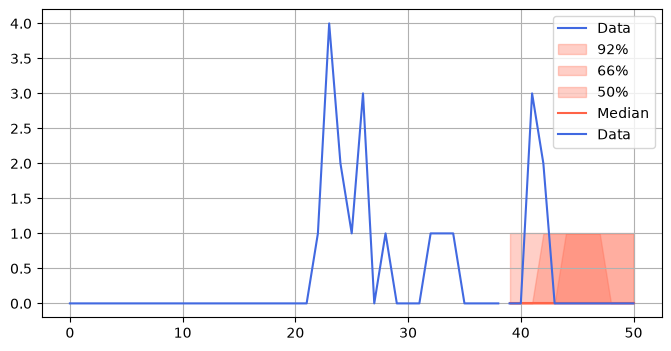

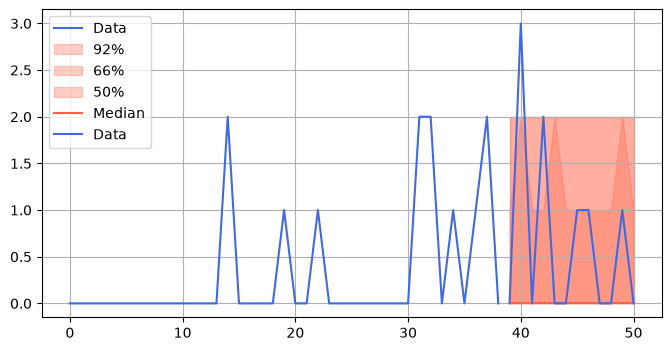

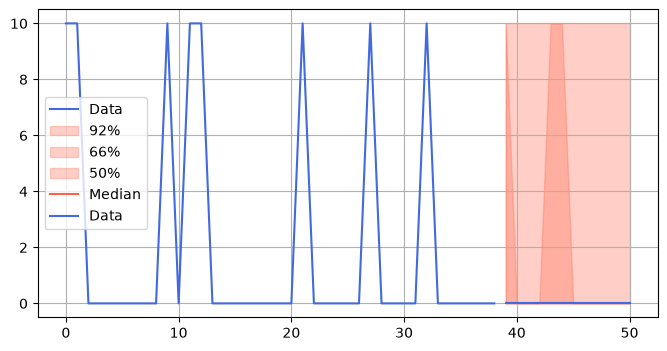

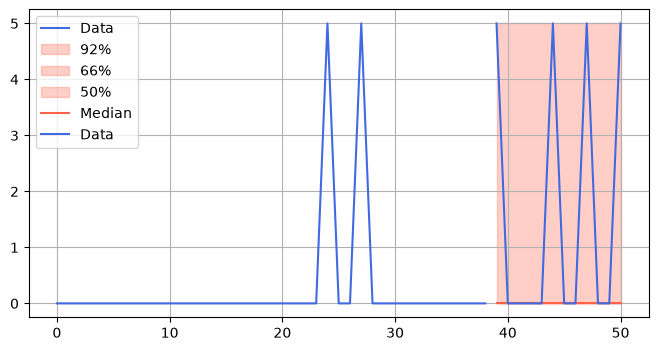

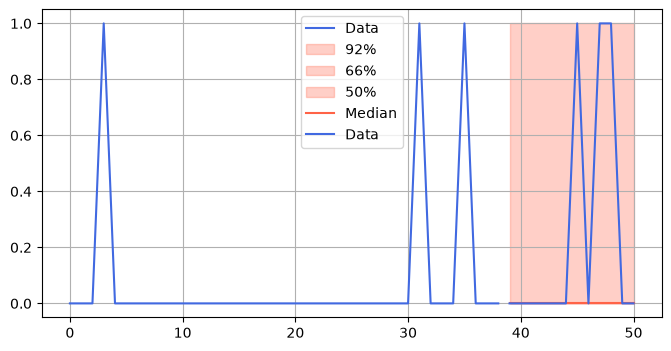

In [4]:
rng = np.random.default_rng(seed=97)
example_series_indices = rng.choice(len(ds_car_parts), size=10)

for i in example_series_indices:
    y_train = ds_car_parts[i]["target"][:-12]
    y_test = ds_car_parts[i]["target"][-12:]

    model = tdx.Threedx(
        period_length=12,
        parameter_grid=parameter_grid,
    )

    model = model.fit(y=y_train, loss=tdx.rmse)

    sample_paths = model.predict(
        horizon=y_test.size,
        n_samples=2501,
        observation_driven=True,
        draw=None,
        seed=823
    )

    plot_forecast(
        forecast=sample_paths,
        y=y_train,
        y_future=y_test
    )

### Hospital

The 767 time series were originally sourced by Hyndman et al. for the "Forecasting with Exponential Smoothing: The State Space Approach" book. From the data's description in the `expsmooth` R package:

> Monthly patient count for products that are related to medical problems. There are 767 time series that had a mean count of at least 10 and no zeros.

Just like for the Car Parts above, assume `period_length=12` and forecast the last observed period (twelve months).

In [5]:
ds_hospital = datasets.load_dataset("autogluon/chronos_datasets", "monash_hospital", split="train")
ds_hospital.set_format("numpy")

print(f"{len(ds_hospital)=}")

len(ds_hospital)=767


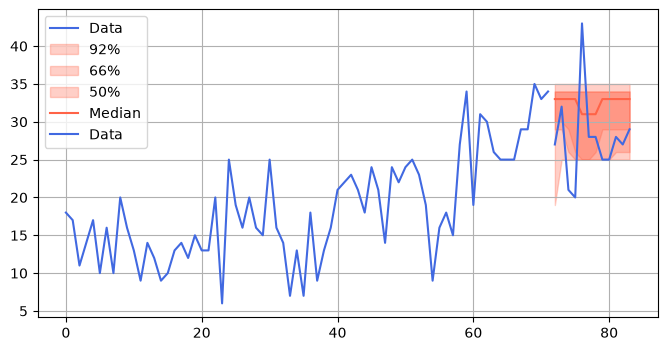

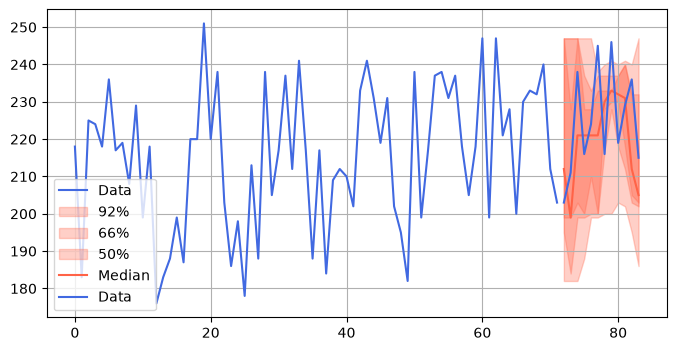

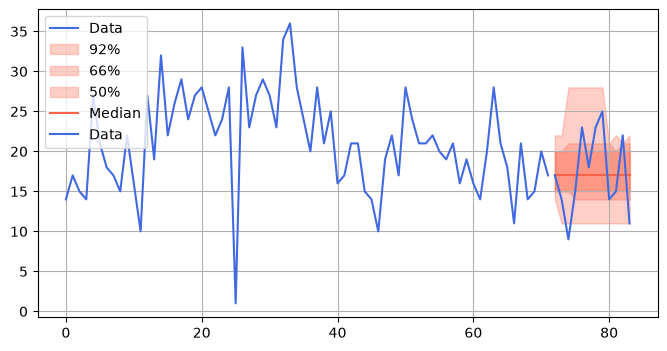

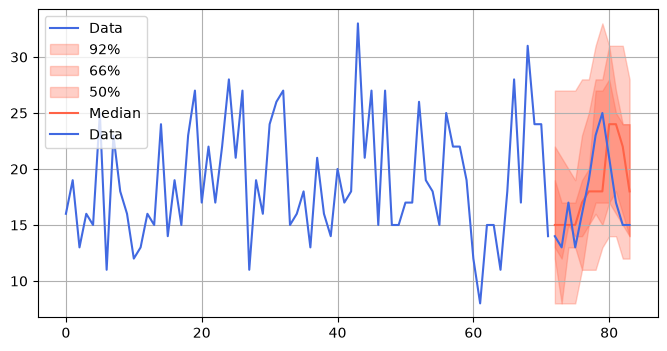

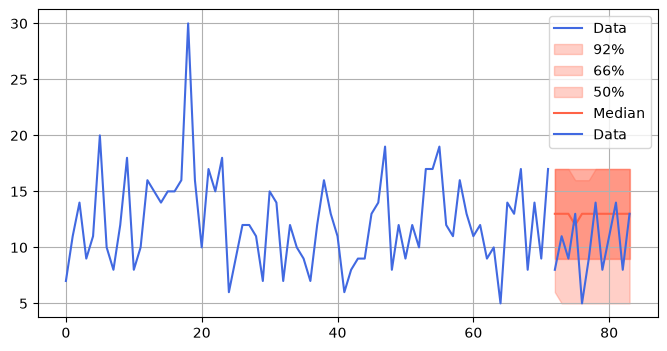

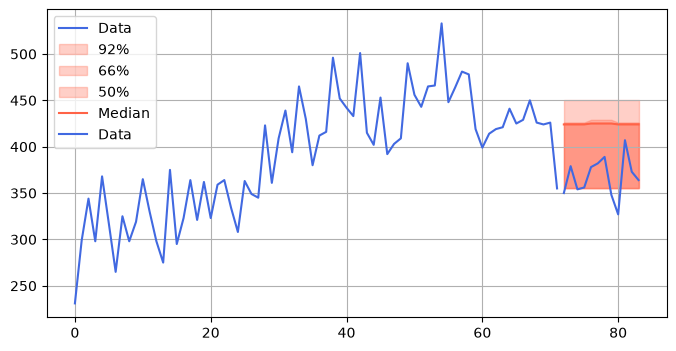

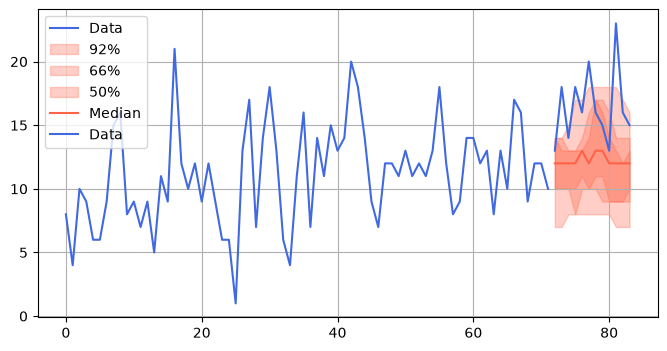

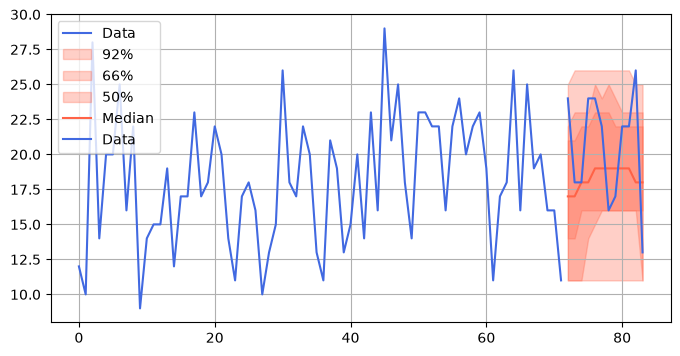

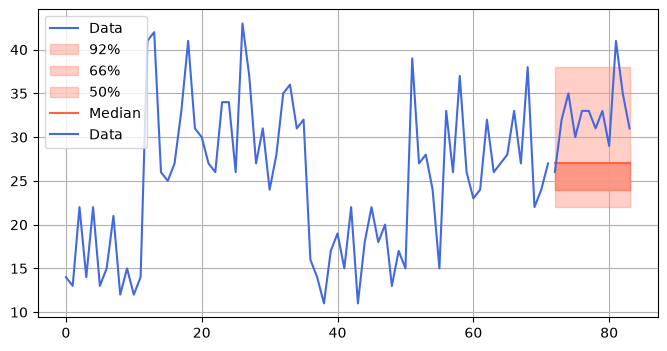

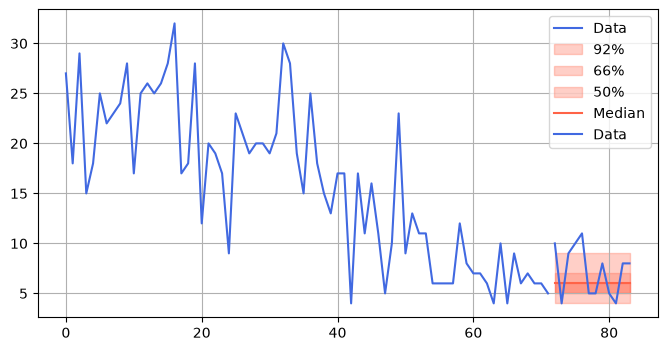

In [6]:
rng = np.random.default_rng(seed=442)
example_series_indices = rng.choice(len(ds_hospital), size=10)

for i in example_series_indices:
    y_train = ds_hospital[i]["target"][:-12]
    y_test = ds_hospital[i]["target"][-12:]

    model = tdx.Threedx(
        period_length=12,
        parameter_grid=parameter_grid,
    )

    model = model.fit(y=y_train, loss=tdx.rmse)

    sample_paths = model.predict(
        horizon=y_test.size,
        n_samples=2501,
        observation_driven=True,
        draw=None,
        seed=823
    )

    plot_forecast(
        forecast=sample_paths,
        y=y_train,
        y_future=y_test
    )

### Uber TLC Daily

Some daily time series related to data published by New York's Taxi and Limousine Commission (TLC) about Uber, sourced originally by [FiveThirtyEight](https://github.com/fivethirtyeight/uber-tlc-foil-response).

Assume a weekly seasonal component with `period_length=7` and predict three periods (21 days) into the future.

In [7]:
ds_uber_daily = datasets.load_dataset("autogluon/chronos_datasets", "uber_tlc_daily", split="train")
ds_uber_daily.set_format("numpy")

print(f"{len(ds_uber_daily)=}")

len(ds_uber_daily)=262


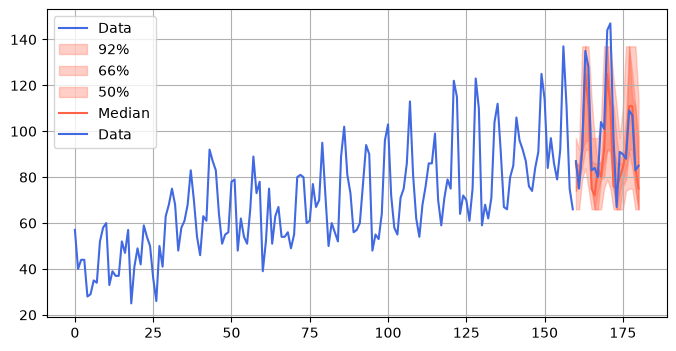

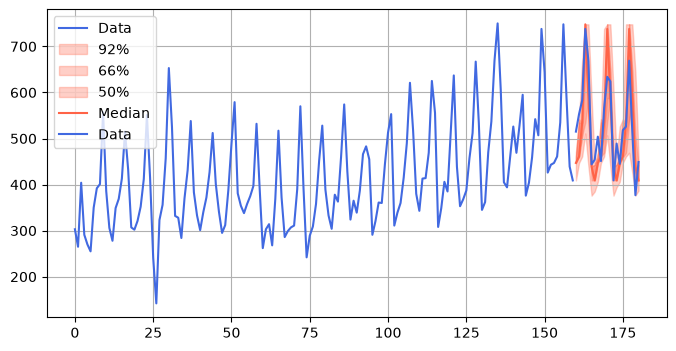

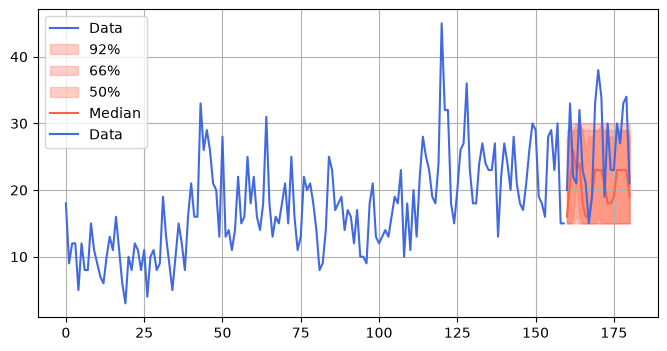

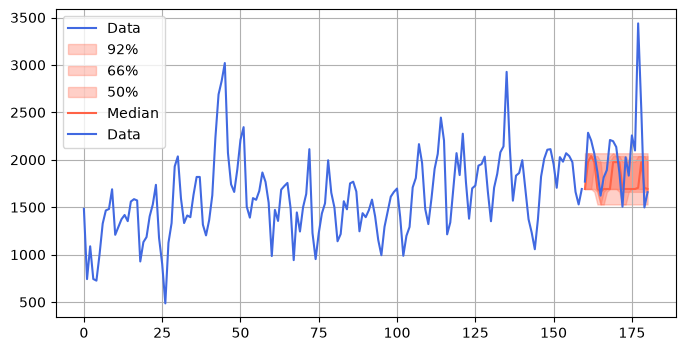

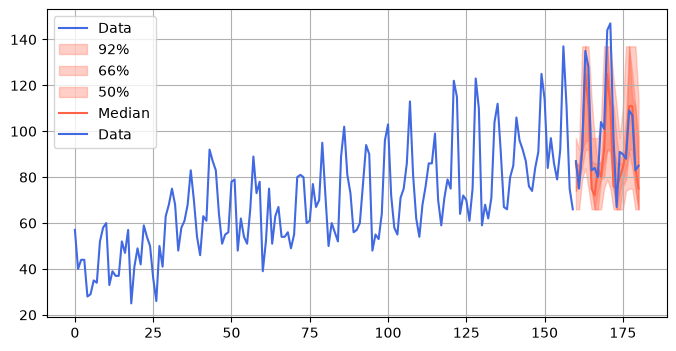

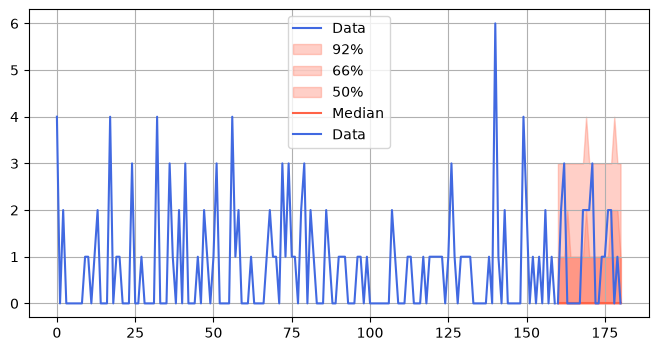

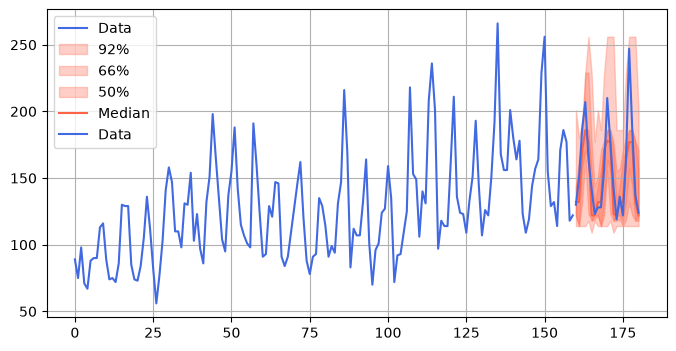

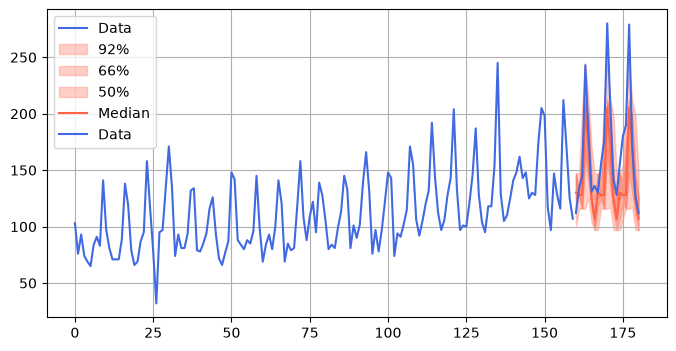

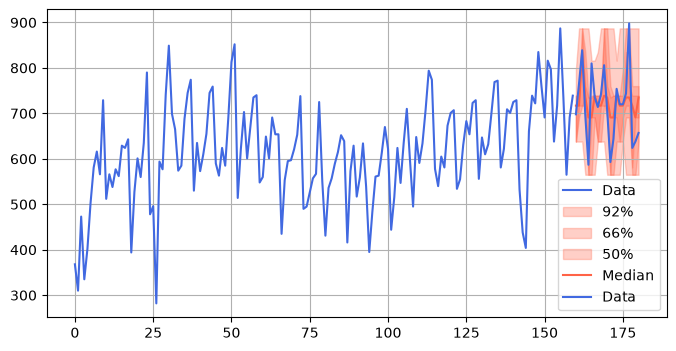

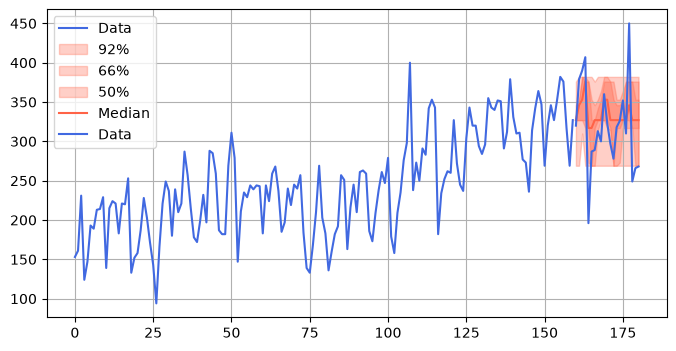

In [8]:
rng = np.random.default_rng(seed=44)
example_series_indices = rng.choice(len(ds_uber_daily), size=10)

for i in example_series_indices:
    y_train = ds_uber_daily[i]["target"][:-21]
    y_test = ds_uber_daily[i]["target"][-21:]

    model = tdx.Threedx(
        period_length=7,
        parameter_grid=parameter_grid,
    )

    model = model.fit(y=y_train, loss=tdx.rmse)

    sample_paths = model.predict(
        horizon=y_test.size,
        n_samples=2501,
        observation_driven=True,
        draw=None,
        seed=823
    )

    plot_forecast(
        forecast=sample_paths,
        y=y_train,
        y_future=y_test
    )

### Wind Farms Daily

Daily observations on 337 wind power production time series aggregated from a dataset included in the [Monash Time Series Forecasting Repository](https://zenodo.org/records/4654909). The time series are fairly long and include missing values in within the first 150 days (observations).

Assume `period_length=7` and predict the last period (seven days). Impute missing values with zero if there are any (as done in the [second published version of the dataset](https://zenodo.org/records/4654858)).

In [9]:
ds_wind_farms_daily = datasets.load_dataset("autogluon/chronos_datasets", "wind_farms_daily", split="train")
ds_wind_farms_daily.set_format("numpy")

print(f"{len(ds_wind_farms_daily)=}")

len(ds_wind_farms_daily)=337


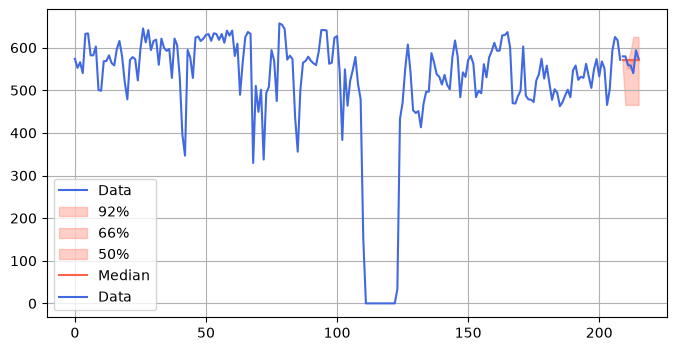

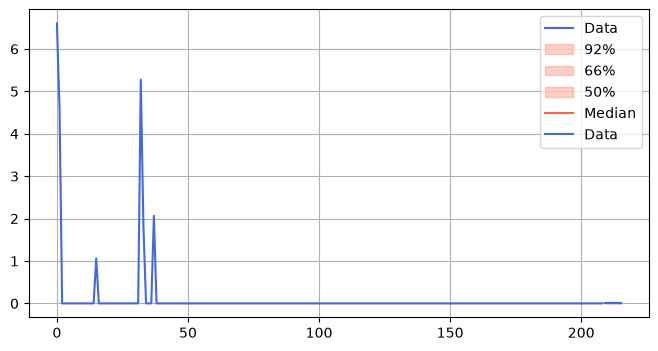

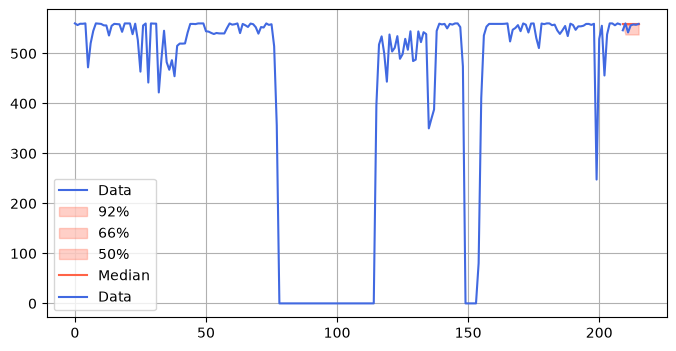

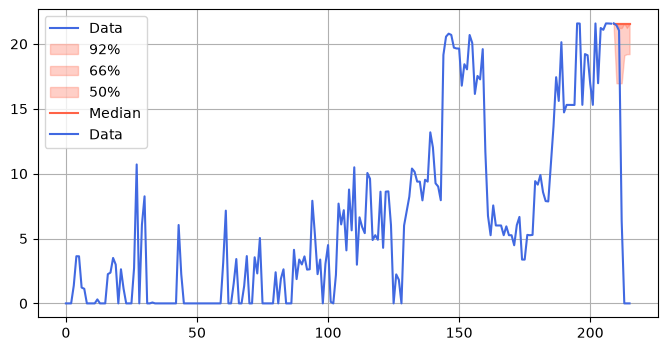

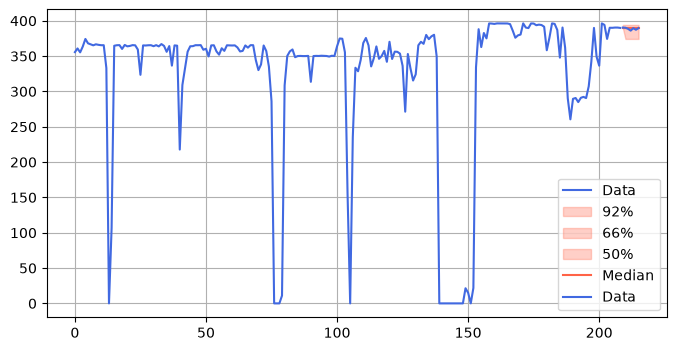

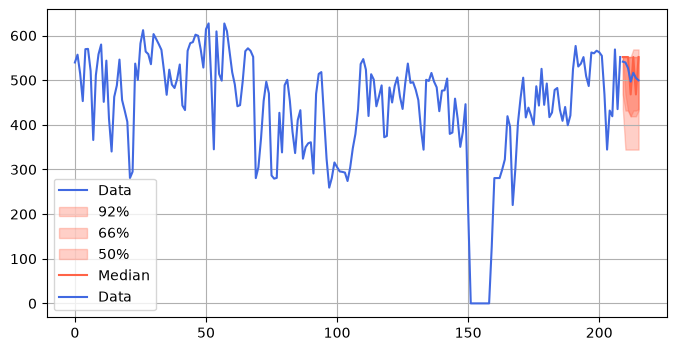

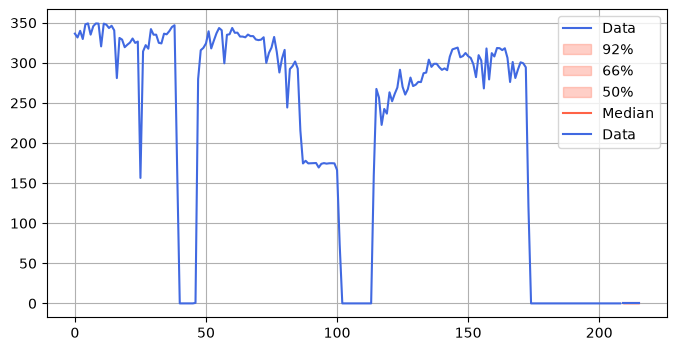

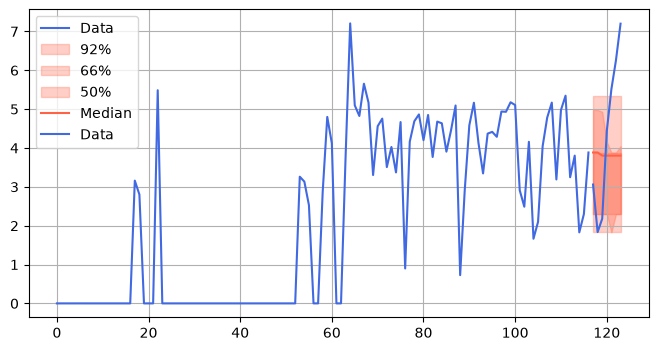

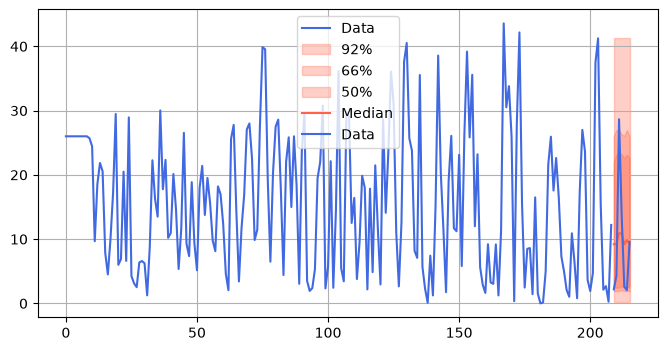

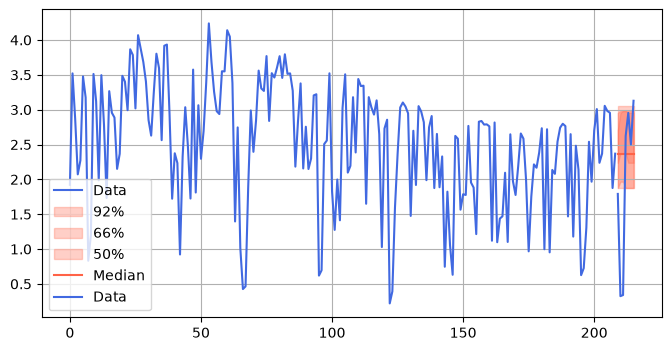

In [10]:
rng = np.random.default_rng(seed=928)
example_series_indices = rng.choice(len(ds_wind_farms_daily), size=10)

for i in example_series_indices:
    y_train = ds_wind_farms_daily[i]["target"][150:-7]
    y_test = ds_wind_farms_daily[i]["target"][-7:]

    model = tdx.Threedx(
        period_length=7,
        parameter_grid=parameter_grid,
    )

    model = model.fit(
        y=np.nan_to_num(y_train, nan=0.0),
        loss=tdx.rmse
    )

    sample_paths = model.predict(
        horizon=y_test.size,
        n_samples=2501,
        observation_driven=True,
        draw=None,
        seed=488
    )

    plot_forecast(
        forecast=sample_paths,
        y=y_train,
        y_future=y_test
    )